In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pyproj import Transformer
from datetime import datetime, timedelta
import pandas as pd


class MBESAnalyzer:
    """Complete MBES bathymetry analysis class - keeps everything organized."""

    def __init__(
        self, file_path, origin=(60.8011575, 10.7122345, 0), nodata_value=9999
    ):
        """Initialize with your MBES file."""
        self.file_path = file_path
        self.origin = origin
        self.nodata_value = nodata_value

        # Data containers
        self.data = None
        self.data_clean = None
        self.extent = None
        self.resolution = None
        self.centerline = None
        self.crs = None

        # Load data immediately
        self._load_data()

    def _load_data(self):
        """Internal method to load and process MBES data."""
        print("🔍 Loading MBES data...")

        # Load from file
        with rasterio.open(self.file_path) as src:
            self.data = src.read(1)
            self.crs = src.crs
            bounds = src.bounds

        # Clean nodata
        self.data_clean = np.where(self.data == self.nodata_value, np.nan, self.data)

        # Convert to local coordinates
        lat0, lon0, h0 = self.origin
        if self.crs.to_string() == "EPSG:4326" or "EPSG:4326" in str(self.crs):
            x_local_min = (bounds.left - lon0) * 111319.9 * np.cos(np.radians(lat0))
            x_local_max = (bounds.right - lon0) * 111319.9 * np.cos(np.radians(lat0))
            y_local_min = (bounds.bottom - lat0) * 110540.0
            y_local_max = (bounds.top - lat0) * 110540.0
        else:
            transformer = Transformer.from_crs(self.crs, "EPSG:4326", always_xy=True)
            corners_x = [bounds.left, bounds.right, bounds.left, bounds.right]
            corners_y = [bounds.bottom, bounds.bottom, bounds.top, bounds.top]
            lon_corners, lat_corners = transformer.transform(corners_x, corners_y)
            x_local_corners = [
                (lon - lon0) * 111319.9 * np.cos(np.radians(lat0))
                for lon in lon_corners
            ]
            y_local_corners = [(lat - lat0) * 110540.0 for lat in lat_corners]
            x_local_min, x_local_max = min(x_local_corners), max(x_local_corners)
            y_local_min, y_local_max = min(y_local_corners), max(y_local_corners)

        self.extent = [x_local_min, x_local_max, y_local_min, y_local_max]
        height, width = self.data_clean.shape
        self.resolution = (self.extent[1] - self.extent[0]) / width

    def print_overview(self):
        """Print comprehensive data overview."""
        print("\n=== MBES DATA OVERVIEW ===")
        print(f"File: {self.file_path}")
        print(f"Origin: {self.origin[0]:.6f}°N, {self.origin[1]:.6f}°E")
        print(f"Shape: {self.data_clean.shape}")
        print(f"Resolution: {self.resolution:.3f}m ({self.resolution*100:.1f}cm/pixel)")
        print(
            f"Data range: {np.nanmin(self.data_clean):.2f} to {np.nanmax(self.data_clean):.2f}m"
        )
        print(
            f"NoData: {np.sum(np.isnan(self.data_clean))/self.data_clean.size*100:.1f}%"
        )

    def plot_bathymetry(self):
        """Plot basic 2D bathymetry map."""
        fig, ax = plt.subplots(figsize=(8, 5))  # Changed from (12, 8)
        im = ax.imshow(
            self.data_clean, extent=self.extent, cmap="terrain", origin="upper"
        )
        plt.colorbar(im, label="Depth/Elevation (m)")
        plt.title("MBES Swath Bathymetry")
        plt.xlabel(f"East (m) from {self.origin[0]:.6f}°, {self.origin[1]:.6f}°")
        plt.ylabel("North (m)")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def extract_centerline(self, start_time="11:58:20", end_time="12:12:36"):
        """Extract vehicle centerline from swath data."""
        start_dt = datetime.strptime(start_time, "%H:%M:%S")
        end_dt = datetime.strptime(end_time, "%H:%M:%S")
        duration = (end_dt - start_dt).total_seconds() / 60

        height, width = self.data_clean.shape
        centerline_data = []

        for row_idx in range(height):
            row_data = self.data_clean[row_idx, :]
            valid_indices = np.where(~np.isnan(row_data))[0]

            if len(valid_indices) > 0:
                left_edge = valid_indices[0]
                right_edge = valid_indices[-1]
                center_col = (left_edge + right_edge) // 2
                center_depth = (
                    row_data[center_col]
                    if not np.isnan(row_data[center_col])
                    else np.nanmean(
                        row_data[max(0, center_col - 2) : min(width, center_col + 3)]
                    )
                )

                centerline_data.append(
                    {
                        "center_col": center_col,
                        "depth": center_depth,
                        "left_edge": left_edge,
                        "right_edge": right_edge,
                        "swath_width": right_edge - left_edge,
                    }
                )
            else:
                centerline_data.append(
                    {
                        "center_col": width // 2,
                        "depth": np.nan,
                        "left_edge": np.nan,
                        "right_edge": np.nan,
                        "swath_width": 0,
                    }
                )

        center_cols = np.array([row["center_col"] for row in centerline_data])
        depths = np.array([row["depth"] for row in centerline_data])

        y_coords = np.linspace(self.extent[3], self.extent[2], height)
        x_coords = self.extent[0] + (self.extent[1] - self.extent[0]) * (
            center_cols / width
        )
        time_array = np.linspace(0, duration, height)

        self.centerline = {
            "x_coords": x_coords,
            "y_coords": y_coords,
            "depths": depths,
            "time_minutes": time_array,
            "swath_data": centerline_data,
        }

        print(
            f"✅ Centerline extracted: {len(x_coords)} points over {duration:.1f} minutes"
        )
        return self.centerline

    def plot_centerline_track(self):
        """Plot bathymetry with vehicle centerline overlay."""
        if self.centerline is None:
            print("❌ No centerline data. Run extract_centerline() first.")
            return

        height, width = self.data_clean.shape
        fig, ax = plt.subplots(figsize=(8, 5))  # Changed from (12, 8)
        im = ax.imshow(
            self.data_clean,
            extent=self.extent,
            cmap="terrain",
            origin="upper",
            alpha=0.8,
        )
        ax.plot(
            self.centerline["x_coords"],
            self.centerline["y_coords"],
            "red",
            linewidth=3,
            label="Vehicle Track",
        )

        # Show sample swath edges
        for i in range(0, height, height // 20):
            row_data = self.data_clean[i, :]
            valid_indices = np.where(~np.isnan(row_data))[0]
            if len(valid_indices) > 0:
                left_col, right_col = valid_indices[0], valid_indices[-1]
                left_x = self.extent[0] + (self.extent[1] - self.extent[0]) * (
                    left_col / width
                )
                right_x = self.extent[0] + (self.extent[1] - self.extent[0]) * (
                    right_col / width
                )
                y_pos = self.extent[3] - (self.extent[3] - self.extent[2]) * (
                    i / height
                )
                ax.plot(
                    [left_x, right_x], [y_pos, y_pos], "yellow", alpha=0.3, linewidth=1
                )

        ax.set_title("MBES with Vehicle Centerline")
        ax.set_xlabel(f"East (m) from {self.origin[0]:.6f}°, {self.origin[1]:.6f}°")
        ax.set_ylabel("North (m)")
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def plot_depth_profile(self):
        """Plot vehicle depth profile over time."""
        if self.centerline is None:
            print("❌ No centerline data. Run extract_centerline() first.")
            return

        fig, ax = plt.subplots(figsize=(7, 4))  # Changed from (10, 6)
        ax.plot(
            self.centerline["time_minutes"],
            self.centerline["depths"],
            "blue",
            linewidth=2,
        )
        ax.set_title("Vehicle Track Depth Profile")
        ax.set_xlabel("Time (minutes from start)")
        ax.set_ylabel("Depth/Elevation (m)")
        ax.grid(True, alpha=0.3)
        ax.invert_yaxis()
        plt.tight_layout()
        plt.show()

    def plot_swath_width(self):
        """Plot swath width variation over time."""
        if self.centerline is None:
            print("❌ No centerline data. Run extract_centerline() first.")
            return

        swath_widths = [
            row["swath_width"] * self.resolution
            for row in self.centerline["swath_data"]
        ]
        fig, ax = plt.subplots(figsize=(7, 4))  # Changed from (10, 6)
        ax.plot(self.centerline["time_minutes"], swath_widths, "green", linewidth=2)
        ax.set_title("MBES Swath Width Over Time")
        ax.set_xlabel("Time (minutes from start)")
        ax.set_ylabel("Swath Width (m)")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def export_centerline(self, filename="mbes_centerline.csv"):
        """Export centerline data to CSV."""
        if self.centerline is None:
            print("❌ No centerline data. Run extract_centerline() first.")
            return

        df = pd.DataFrame(
            {
                "time_minutes": self.centerline["time_minutes"],
                "east_m": self.centerline["x_coords"],
                "north_m": self.centerline["y_coords"],
                "depth_m": self.centerline["depths"],
            }
        )

        df_clean = df.dropna()
        df_clean.to_csv(filename, index=False)
        print(f"✅ Exported {len(df_clean)} points to: {filename}")
        return df_clean

In [8]:
# mbes_flatten_viz.py  (fixed, memory-safe)
from __future__ import annotations
import numpy as np
from dataclasses import dataclass
from typing import Literal, Optional, Tuple, Dict
import matplotlib.pyplot as plt

try:
    import rasterio
except Exception:
    rasterio = None

try:
    from scipy.ndimage import gaussian_filter
except Exception:
    gaussian_filter = None


# ---------------------- helpers ----------------------


def _xy_from_affine(transform, rows, cols):
    """
    Pixel-center XY from rasterio Affine (vectorized for grids/blocks).
    rows, cols can be 2D grids (meshgrid with indexing='ij').
    """
    a, b, c, d, e, f = (
        transform.a,
        transform.b,
        transform.c,
        transform.d,
        transform.e,
        transform.f,
    )
    x = c + a * cols + b * rows + 0.5 * (a + b)
    y = f + d * cols + e * rows + 0.5 * (d + e)
    return x, y


def _poly_design(x, y, order: int) -> Tuple[np.ndarray, Dict]:
    """Build polynomial design up to 'order' with normalization for stability."""
    x0, y0 = float(np.nanmean(x)), float(np.nanmean(y))
    sx = float(np.nanstd(x)) or 1.0
    sy = float(np.nanstd(y)) or 1.0
    X = (x - x0) / sx
    Y = (y - y0) / sy

    if order == 1:
        terms = [np.ones_like(X), X, Y]
    elif order == 2:
        terms = [np.ones_like(X), X, Y, X**2, X * Y, Y**2]
    elif order == 3:
        terms = [
            np.ones_like(X),
            X,
            Y,
            X**2,
            X * Y,
            Y**2,
            X**3,
            (X**2) * Y,
            X * (Y**2),
            Y**3,
        ]
    else:
        raise ValueError("poly_order must be 1, 2, or 3")

    A = np.stack(terms, axis=1)
    scale = dict(x0=x0, y0=y0, sx=sx, sy=sy, order=order)
    return A, scale


def _poly_eval_grid(
    coeffs_f32: np.ndarray, transform, H, W, scale: Dict, chunk_rows: int = 256
) -> np.ndarray:
    """
    Evaluate fitted polynomial on the full grid in chunks (memory-friendly).
    Uses float32 throughout to keep memory low.
    """
    trend = np.full((H, W), np.nan, dtype=np.float32)
    a, b, c, d, e, f = (
        transform.a,
        transform.b,
        transform.c,
        transform.d,
        transform.e,
        transform.f,
    )

    cols = np.arange(W, dtype=np.float32)[None, :]  # (1, W)
    for r0 in range(0, H, chunk_rows):
        r1 = min(r0 + chunk_rows, H)
        rows_block = np.arange(r0, r1, dtype=np.float32)[:, None]  # (R,1)

        # Pixel-center XY for this block (float32)
        x = (c + a * cols + b * rows_block + 0.5 * (a + b)).astype(np.float32)
        y = (f + d * cols + e * rows_block + 0.5 * (d + e)).astype(np.float32)

        # Normalize
        X = (x - np.float32(scale["x0"])) / np.float32(scale["sx"] or 1.0)
        Y = (y - np.float32(scale["y0"])) / np.float32(scale["sy"] or 1.0)

        o = scale["order"]
        if o == 1:
            tstack = np.stack([np.ones_like(X), X, Y], axis=-1).astype(np.float32)
        elif o == 2:
            tstack = np.stack(
                [np.ones_like(X), X, Y, X**2, X * Y, Y**2], axis=-1
            ).astype(np.float32)
        else:
            tstack = np.stack(
                [
                    np.ones_like(X),
                    X,
                    Y,
                    X**2,
                    X * Y,
                    Y**2,
                    X**3,
                    (X**2) * Y,
                    X * (Y**2),
                    Y**3,
                ],
                axis=-1,
            ).astype(np.float32)

        # tensordot -> (R,W)
        trend[r0:r1, :] = np.tensordot(tstack, coeffs_f32, axes=([-1], [0])).astype(
            np.float32
        )

    return trend


def _huber_weights(resid, delta=1.5):
    a = np.abs(resid) <= delta
    w = np.empty_like(resid)
    w[a] = 1.0
    w[~a] = delta / (np.abs(resid[~a]) + 1e-12)
    return w


def _robust_poly_fit(x, y, z, order: int, iters: int = 4, max_points: int = 300_000):
    """
    Robust polynomial fit z ~ f(x,y). Operates in float64 for stability.
    Downsamples to max_points to control memory/time.
    """
    n = len(z)
    if n == 0:
        raise ValueError("No valid samples for polynomial fit.")
    if n > max_points:
        idx = np.random.default_rng(0).choice(n, size=max_points, replace=False)
        x, y, z = x[idx], y[idx], z[idx]

    x = x.astype(np.float64, copy=False)
    y = y.astype(np.float64, copy=False)
    z = z.astype(np.float64, copy=False)

    A, scale = _poly_design(x, y, order)
    coeffs, *_ = np.linalg.lstsq(A, z, rcond=None)

    for _ in range(iters):
        r = z - A @ coeffs
        mad = np.median(np.abs(r - np.median(r))) + 1e-9
        w = _huber_weights(r / (1.4826 * mad), delta=1.5)
        Aw = A * w[:, None]
        zw = z * w
        coeffs, *_ = np.linalg.lstsq(Aw, zw, rcond=None)

    return coeffs, scale


def _nan_gaussian(data: np.ndarray, sigma_y: float, sigma_x: float) -> np.ndarray:
    """NaN-aware Gaussian smoothing via weight normalization (float32)."""
    if gaussian_filter is None:
        raise ImportError("scipy is required for gaussian detrend: pip install scipy")
    nan_mask = ~np.isfinite(data)
    base = data.copy()
    base[nan_mask] = 0.0
    w = np.ones_like(data, dtype=np.float32)
    w[nan_mask] = 0.0
    smooth = gaussian_filter(base, sigma=(sigma_y, sigma_x), mode="nearest")
    w_smooth = gaussian_filter(w, sigma=(sigma_y, sigma_x), mode="nearest")
    with np.errstate(invalid="ignore", divide="ignore"):
        smooth = smooth / w_smooth
    smooth[w_smooth == 0] = np.nan
    return smooth.astype(np.float32)


# ---------------------- main detrend ----------------------


def detrend_bathymetry(
    elevation_data: np.ndarray,
    transform,
    mode: Literal["poly", "gauss"] = "poly",
    poly_order: int = 2,
    robust_iters: int = 4,
    max_fit_points: int = 300_000,
    gauss_sigma_m: float = 10.0,
    eval_chunk_rows: int = 256,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Return (residuals, trend). Uses float32 for large arrays.
    """
    # keep big arrays in float32
    z = elevation_data.astype(np.float32, copy=False)
    H, W = z.shape
    valid = np.isfinite(z)

    if mode == "poly":
        # Get valid sample coordinates (1D!) — NO broadcasting
        rows, cols = np.where(valid)

        # Convert pixel indices to XY meters at pixel centers (1D)
        a, b, c, d, e, f = (
            transform.a,
            transform.b,
            transform.c,
            transform.d,
            transform.e,
            transform.f,
        )
        rows_f = rows.astype(np.float64)
        cols_f = cols.astype(np.float64)
        x = c + a * cols_f + b * rows_f + 0.5 * (a + b)
        y = f + d * cols_f + e * rows_f + 0.5 * (d + e)

        z_samples = z[rows, cols].astype(np.float64)

        coeffs64, scale = _robust_poly_fit(
            x,
            y,
            z_samples,
            order=poly_order,
            iters=robust_iters,
            max_points=max_fit_points,
        )

        # Evaluate on the full grid in float32 chunks
        coeffs32 = coeffs64.astype(np.float32)
        trend = _poly_eval_grid(
            coeffs32, transform, H, W, scale, chunk_rows=eval_chunk_rows
        )

        residuals = (z - trend).astype(np.float32)
        residuals[~valid] = np.nan
        trend[~valid] = np.nan
        return residuals, trend

    elif mode == "gauss":
        # convert desired sigma (meters) → pixels
        dx = abs(getattr(transform, "a", 1.0)) or 1.0
        dy = abs(getattr(transform, "e", 1.0)) or 1.0
        sigma_x = max(gauss_sigma_m / dx, 0.1)
        sigma_y = max(gauss_sigma_m / dy, 0.1)
        trend = _nan_gaussian(z, sigma_y=float(sigma_y), sigma_x=float(sigma_x))
        residuals = (z - trend).astype(np.float32)
        return residuals, trend

    else:
        raise ValueError("mode must be 'poly' or 'gauss'")


def save_residual_geotiff(
    out_path: str,
    residuals: np.ndarray,
    reference_path: Optional[str] = None,
    transform=None,
    crs=None,
    nodata_value: float = np.nan,
):
    """Save residuals to GeoTIFF."""
    if rasterio is None:
        raise ImportError("rasterio is required to save GeoTIFFs: pip install rasterio")

    data = residuals.astype("float32", copy=False)

    if reference_path is not None:
        with rasterio.open(reference_path) as src:
            profile = src.profile
            profile.update(count=1, dtype="float32", compress="deflate")
            if not np.isnan(nodata_value):
                profile.update(nodata=nodata_value)
            with rasterio.open(out_path, "w", **profile) as dst:
                if np.isnan(nodata_value):
                    mask = ~np.isfinite(data)
                    data = np.nan_to_num(data, nan=0.0)
                    dst.write(data, 1)
                    dst.write_mask((~mask).astype("uint8") * 255)
                else:
                    data = np.where(np.isfinite(data), data, nodata_value).astype(
                        "float32"
                    )
                    dst.write(data, 1)
    else:
        if transform is None or crs is None:
            raise ValueError("Provide reference_path OR (transform and crs).")
        H, W = data.shape
        profile = dict(
            driver="GTiff",
            height=H,
            width=W,
            count=1,
            dtype="float32",
            crs=crs,
            transform=transform,
            compress="deflate",
        )
        if not np.isnan(nodata_value):
            profile["nodata"] = nodata_value
        with rasterio.open(out_path, "w", **profile) as dst:
            if np.isnan(nodata_value):
                mask = ~np.isfinite(data)
                data = np.nan_to_num(data, nan=0.0)
                dst.write(data, 1)
                dst.write_mask((~mask).astype("uint8") * 255)
            else:
                data = np.where(np.isfinite(data), data, nodata_value).astype("float32")
                dst.write(data, 1)


# ---------------------- convenience class ----------------------


@dataclass
class MBESDetrender:
    path: str
    nodata_value: Optional[float] = None  # if None, use raster's nodata

    # Filled by load()
    data: Optional[np.ndarray] = None
    transform: Optional[object] = None
    crs: Optional[object] = None
    bounds: Optional[object] = None
    extent: Optional[Tuple[float, float, float, float]] = (
        None  # (left, right, bottom, top)
    )

    # Results
    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None
    meta: Optional[dict] = None  # stores mode and params

    def load(self):
        if rasterio is None:
            raise ImportError("rasterio is required: pip install rasterio")
        with rasterio.open(self.path) as src:
            z = src.read(1)
            self.transform = src.transform
            self.crs = src.crs
            self.bounds = src.bounds
            self.extent = (
                self.bounds.left,
                self.bounds.right,
                self.bounds.bottom,
                self.bounds.top,
            )
            nd = src.nodata if self.nodata_value is None else self.nodata_value
        # to float32 + NaN clean
        z = z.astype(np.float32, copy=False)
        if nd is not None and np.isfinite(nd):
            z[z == nd] = np.nan
        self.data = z
        return self

    def detrend(
        self,
        mode: Literal["poly", "gauss"] = "poly",
        poly_order: int = 2,
        robust_iters: int = 4,
        max_fit_points: int = 300_000,
        gauss_sigma_m: float = 10.0,
        eval_chunk_rows: int = 256,
    ):
        if self.data is None:
            self.load()
        residuals, trend = detrend_bathymetry(
            self.data,
            self.transform,
            mode=mode,
            poly_order=poly_order,
            robust_iters=robust_iters,
            max_fit_points=max_fit_points,
            gauss_sigma_m=gauss_sigma_m,
            eval_chunk_rows=eval_chunk_rows,
        )
        self.residuals = residuals
        self.trend = trend
        self.meta = dict(
            mode=mode,
            poly_order=poly_order,
            gauss_sigma_m=gauss_sigma_m,
            robust_iters=robust_iters,
            max_fit_points=max_fit_points,
            eval_chunk_rows=eval_chunk_rows,
        )
        return self

    # ------------- plotting -------------

    def _auto_vlim(self, arr: np.ndarray, pct: float = 99.0) -> float:
        a = np.abs(arr[np.isfinite(arr)])
        if a.size == 0:
            return 1.0
        return float(np.percentile(a, pct))

    def plot_original(self, figsize=(7, 6), cmap="terrain"):
        if self.data is None:
            self.load()
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(self.data, extent=self.extent, origin="upper", cmap=cmap)
        plt.colorbar(im, ax=ax, label="Depth / elevation (m)")
        ax.set_aspect("equal")
        ax.set_title("Original MBES bathymetry")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        plt.tight_layout()
        return fig, ax

    def plot_trend(self, figsize=(7, 6), cmap="terrain"):
        if self.trend is None:
            raise RuntimeError("Run .detrend(...) first to compute trend.")
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(self.trend, extent=self.extent, origin="upper", cmap=cmap)
        plt.colorbar(im, ax=ax, label="Trend (m)")
        ax.set_aspect("equal")
        mode = self.meta.get("mode") if self.meta else "poly"
        subtitle = f"({mode}"
        if mode == "poly":
            subtitle += f", order={self.meta.get('poly_order', 2)})"
        else:
            subtitle += f", σ≈{self.meta.get('gauss_sigma_m', 10.0)} m)"
        ax.set_title("Estimated large-scale trend\n" + subtitle)
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        plt.tight_layout()
        return fig, ax

    def plot_residuals(
        self, figsize=(7, 6), cmap="RdBu_r", vlim: Optional[float] = None
    ):
        if self.residuals is None:
            raise RuntimeError("Run .detrend(...) first to compute residuals.")
        if vlim is None:
            vlim = self._auto_vlim(self.residuals, pct=99.0)
        fig, ax = plt.subplots(figsize=figsize)
        im = ax.imshow(
            self.residuals,
            extent=self.extent,
            origin="upper",
            cmap=cmap,
            vmin=-vlim,
            vmax=+vlim,
        )
        plt.colorbar(im, ax=ax, label="Residual (m)")
        ax.set_aspect("equal")
        ax.set_title("Detrended (local variations only)")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        plt.tight_layout()
        return fig, ax

    def plot_triptych(
        self,
        figsize=(18, 6),
        cmap_orig="terrain",
        cmap_trend="terrain",
        cmap_resid="RdBu_r",
        vlim_resid: Optional[float] = None,
        save_path: Optional[str] = None,
        dpi: int = 150,
    ):
        if self.data is None:
            self.load()
        if self.trend is None or self.residuals is None:
            raise RuntimeError("Run .detrend(...) first to compute trend/residuals.")
        if vlim_resid is None:
            vlim_resid = self._auto_vlim(self.residuals, pct=99.0)

        fig, axes = plt.subplots(1, 3, figsize=figsize)

        im0 = axes[0].imshow(
            self.data, extent=self.extent, origin="upper", cmap=cmap_orig
        )
        axes[0].set_title("Original")
        axes[0].set_aspect("equal")
        axes[0].set_xlabel("Easting (m)")
        axes[0].set_ylabel("Northing (m)")
        plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="m")

        im1 = axes[1].imshow(
            self.trend, extent=self.extent, origin="upper", cmap=cmap_trend
        )
        mode = self.meta.get("mode") if self.meta else "poly"
        subtitle = f"{mode}"
        if mode == "poly":
            subtitle += f" (order {self.meta.get('poly_order', 2)})"
        else:
            subtitle += f" (σ≈{self.meta.get('gauss_sigma_m', 10.0)} m)"
        axes[1].set_title(f"Estimated trend\n{subtitle}")
        axes[1].set_aspect("equal")
        axes[1].set_xlabel("Easting (m)")
        axes[1].set_ylabel("Northing (m)")
        plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="m")

        im2 = axes[2].imshow(
            self.residuals,
            extent=self.extent,
            origin="upper",
            cmap=cmap_resid,
            vmin=-vlim_resid,
            vmax=+vlim_resid,
        )
        axes[2].set_title("Residuals (local variations)")
        axes[2].set_aspect("equal")
        axes[2].set_xlabel("Easting (m)")
        axes[2].set_ylabel("Northing (m)")
        plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04, label="m")

        plt.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=dpi, bbox_inches="tight")
        return fig, axes

    def save_residual_geotiff(self, out_path: str, nodata_value: float = np.nan):
        if self.residuals is None:
            raise RuntimeError("Run .detrend(...) first.")
        save_residual_geotiff(
            out_path,
            self.residuals,
            reference_path=self.path,
            nodata_value=nodata_value,
        )

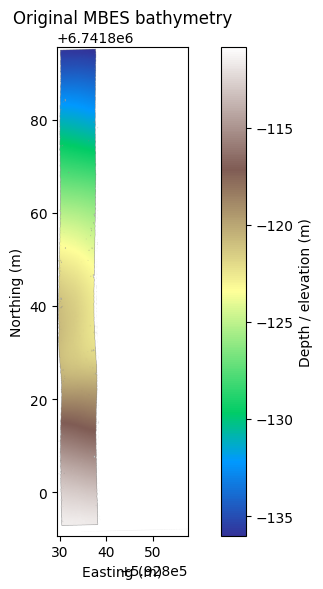

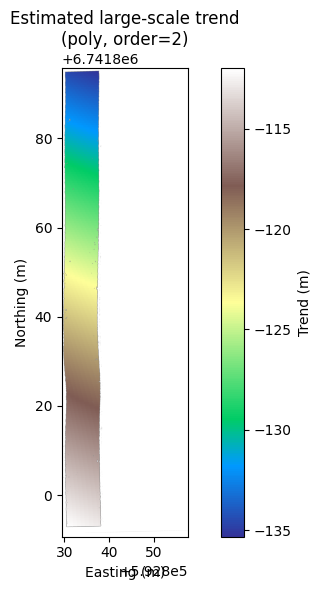

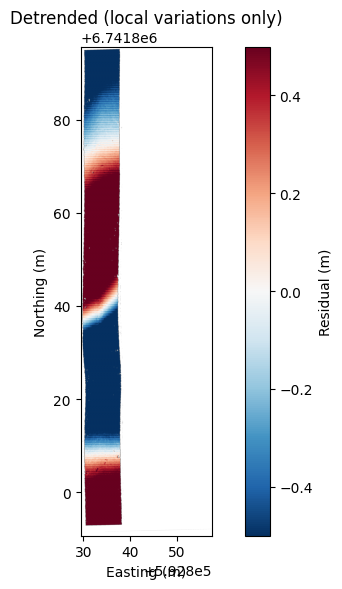

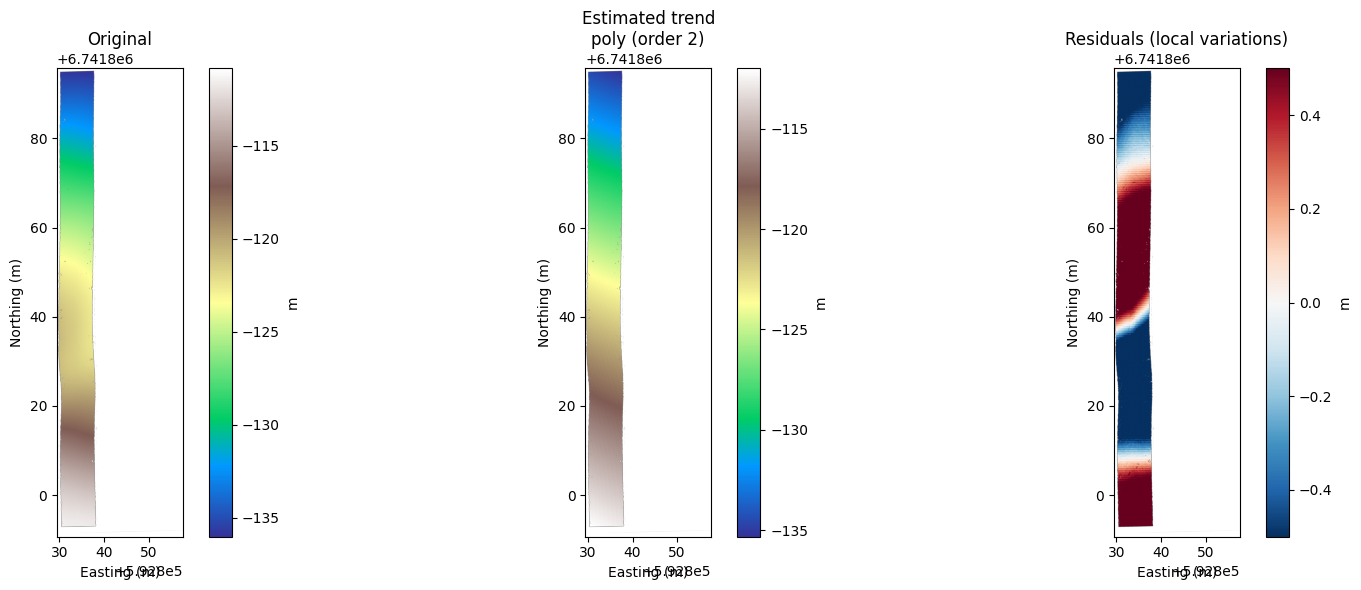

In [9]:
mb = MBESDetrender(r"E:\mjosa_new\DTM\geotiff_2.tif").load()

# Option A: 2D polynomial (good default), with small chunks to save RAM
mb.detrend(mode="poly", poly_order=2, eval_chunk_rows=256, max_fit_points=300_000)

# Option B: Gaussian high-pass (set feature scale in meters)
# mb.detrend(mode="gauss", gauss_sigma_m=12)

# Plots
mb.plot_original()
mb.plot_trend()
mb.plot_residuals(vlim=0.5)
mb.plot_triptych(save_path="mbes_triptych.png", vlim_resid=0.5)

# Optional export
mb.save_residual_geotiff("mbes_detrended_poly2.tif")

In [10]:
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from dataclasses import dataclass
from typing import Optional, Tuple
from scipy.ndimage import gaussian_filter1d
from scipy.stats import median_abs_deviation

# ------------------------
# MBES detrending (separable)
# ------------------------


@dataclass
class MBESDetrender:
    tif_path: str
    nodata_value: Optional[float] = 9999.0  # change if needed
    # smoothing in meters (converted to rows by pixel size in Y)
    smooth_baseline_m: float = 10.0  # along-track smoothing of A(y)
    smooth_tilt_m: float = 20.0  # along-track smoothing of B(y)
    # robust row fit options
    max_row_iters: int = 2  # a couple of robust passes is plenty
    slope_clip_sigma: float = 6.0  # clip insane row slopes
    intercept_clip_sigma: float = 6.0  # clip insane row intercepts

    # internals filled after load()/detrend()
    data: Optional[np.ndarray] = None
    transform: Optional[object] = None
    crs_epsg: Optional[int] = None
    extent: Optional[Tuple[float, float, float, float]] = (
        None  # (xmin, xmax, ymin, ymax)
    )
    px_y: Optional[float] = None
    px_x: Optional[float] = None
    x_cols: Optional[np.ndarray] = None  # 1D easting of each column (m)
    y_rows: Optional[np.ndarray] = None  # 1D northing of each row (m)
    baseline_A: Optional[np.ndarray] = None  # per-row intercept at x0 (m)
    tilt_B: Optional[np.ndarray] = None  # per-row slope (m/m)
    baseline_A_s: Optional[np.ndarray] = None
    tilt_B_s: Optional[np.ndarray] = None
    trend: Optional[np.ndarray] = None
    residuals: Optional[np.ndarray] = None

    # ---------- I/O ----------
    def load(self):
        """Load GeoTIFF, clean nodata, prepare 1D coordinates and extent."""
        with rasterio.open(self.tif_path) as src:
            z = src.read(1).astype(np.float64)
            tf = src.transform
            self.transform = tf
            self.crs_epsg = src.crs.to_epsg()
            bounds = src.bounds

        # replace nodata with NaN
        if self.nodata_value is not None:
            z = np.where(z == self.nodata_value, np.nan, z)

        self.data = z

        # transform parameters
        a, b, c, d, e, f = (
            self.transform.a,
            self.transform.b,
            self.transform.c,
            self.transform.d,
            self.transform.e,
            self.transform.f,
        )

        # sanity: we assume north-up rasters (b≈0, d≈0)
        if abs(b) > 1e-10 or abs(d) > 1e-10:
            print(
                "⚠️ This code assumes north-up rasters (no rotation). Your GeoTIFF looks rotated.\n"
                "It may still work row-by-row but coordinates will be approximate."
            )

        # 1D coords for columns/rows (pixel centers)
        H, W = z.shape
        cols = np.arange(W)
        rows = np.arange(H)
        self.x_cols = c + a * (cols + 0.5)  # easting
        self.y_rows = f + e * (rows + 0.5)  # northing (note: e is usually negative)

        self.px_x = abs(a)
        self.px_y = abs(e)

        self.extent = (
            float(bounds.left),
            float(bounds.right),
            float(bounds.bottom),
            float(bounds.top),
        )

        return self

    # ---------- detrend core ----------
    def detrend(
        self,
        smooth_baseline_m: Optional[float] = None,
        smooth_tilt_m: Optional[float] = None,
        robust: bool = True,
        remove_cross_track_tilt: bool = True,
    ):
        """
        Build separable trend: trend(y,x) = A_s(y) + B_s(y) * (x - x0).
        A_s, B_s are per-row (y) smoothed baseline and tilt.
        """
        if self.data is None:
            self.load()

        if smooth_baseline_m is not None:
            self.smooth_baseline_m = float(smooth_baseline_m)
        if smooth_tilt_m is not None:
            self.smooth_tilt_m = float(smooth_tilt_m)

        z = self.data
        H, W = z.shape
        x = self.x_cols

        # center x once so intercepts are "depth at swath center"
        x0 = 0.5 * (x[0] + x[-1])
        xc = x - x0

        A = np.full(H, np.nan, dtype=np.float64)  # per-row intercept at x0
        B = np.full(H, 0.0, dtype=np.float64)  # per-row slope

        # robust row-by-row line fits
        for i in range(H):
            row = z[i, :]
            m = np.isfinite(row)
            if m.sum() < 5:
                continue

            xi = xc[m]
            yi = row[m]

            # initial least squares
            b1, a1 = np.polyfit(xi, yi, 1)  # y = a1 + b1*xc
            ai, bi = a1, b1

            if robust:
                # a couple of simple robust reweighting passes
                for _ in range(self.max_row_iters):
                    resid = yi - (ai + bi * xi)
                    s = median_abs_deviation(resid, scale="normal") or np.nanstd(resid)
                    if not np.isfinite(s) or s == 0:
                        break
                    w = 1.0 / (
                        1.0 + (resid / (3.0 * s)) ** 2
                    )  # gentle Tukey-ish weights
                    # weighted least squares via normal equations
                    W = np.diag(w)
                    X = np.column_stack([np.ones_like(xi), xi])
                    beta = np.linalg.lstsq(W @ X, W @ yi, rcond=None)[0]
                    ai, bi = float(beta[0]), float(beta[1])

            A[i] = ai
            B[i] = bi if remove_cross_track_tilt else 0.0

        # clip crazy rows (bad data gaps etc.)
        def _clip_series(series, sigma=6.0):
            s = series.copy()
            m = np.isfinite(s)
            if m.sum() < 5:
                return s
            med = np.nanmedian(s[m])
            mad = median_abs_deviation(s[m], scale="normal") or np.nanstd(s[m])
            if mad == 0 or not np.isfinite(mad):
                return s
            lo, hi = med - sigma * mad, med + sigma * mad
            s[(s < lo) | (s > hi)] = np.nan
            # refill clipped with nearest valid
            good = np.where(np.isfinite(s))[0]
            if good.size >= 2:
                s = np.interp(np.arange(len(s)), good, s[good])
            return s

        A = _clip_series(A, self.intercept_clip_sigma)
        B = _clip_series(B, self.slope_clip_sigma)

        # smooth along-track (in rows)
        sigmaA = max(0.5, self.smooth_baseline_m / (self.px_y or 1.0))
        sigmaB = max(0.5, self.smooth_tilt_m / (self.px_y or 1.0))
        A_s = gaussian_filter1d(A, sigma=sigmaA, mode="nearest", truncate=3.5)
        B_s = gaussian_filter1d(B, sigma=sigmaB, mode="nearest", truncate=3.5)

        # build trend by broadcasting (no giant XY grids)
        trend = A_s[:, None] + B_s[:, None] * xc[None, :]

        # residuals (keep NaNs where input was NaN)
        resid = z - trend
        resid[~np.isfinite(z)] = np.nan

        # store
        self.baseline_A, self.tilt_B = A, B
        self.baseline_A_s, self.tilt_B_s = A_s, B_s
        self.trend = trend
        self.residuals = resid
        return self

    # ---------- plotting helpers ----------
    def _extent_imshow(self):
        # imshow expects (xmin, xmax, ymin, ymax)
        return (self.extent[0], self.extent[1], self.extent[2], self.extent[3])

    def _robust_sym_vlim(self, arr, q=0.98):
        m = np.isfinite(arr)
        if not m.any():
            return (-1, 1)
        lo, hi = np.nanquantile(arr[m], [(1 - q) / 2, 1 - (1 - q) / 2])
        vmax = max(abs(lo), abs(hi))
        if not np.isfinite(vmax) or vmax == 0:
            vmax = np.nanstd(arr[m]) * 3 or 1.0
        return (-vmax, vmax)

    def plot_triptych(
        self, cmap_orig="terrain", cmap_resid="RdBu_r", figsize=(14, 4.8)
    ):
        """Original | Trend | Residuals (three panels)"""
        assert (
            self.data is not None
            and self.trend is not None
            and self.residuals is not None
        ), "Run load() and detrend() first."

        fig, axs = plt.subplots(1, 3, figsize=figsize, constrained_layout=True)

        # 1) original
        im0 = axs[0].imshow(
            self.data, extent=self._extent_imshow(), origin="upper", cmap=cmap_orig
        )
        axs[0].set_title("Original")
        axs[0].set_xlabel("Easting (m)")
        axs[0].set_ylabel("Northing (m)")
        cbar0 = fig.colorbar(im0, ax=axs[0])
        cbar0.set_label("Depth (m)")

        # 2) trend
        im1 = axs[1].imshow(
            self.trend, extent=self._extent_imshow(), origin="upper", cmap=cmap_orig
        )
        axs[1].set_title("Estimated trend\nA(y) + B(y)·(x−x₀)")
        axs[1].set_xlabel("Easting (m)")
        axs[1].set_ylabel("Northing (m)")
        cbar1 = fig.colorbar(im1, ax=axs[1])
        cbar1.set_label("Depth (m)")

        # 3) residuals
        vmin, vmax = self._robust_sym_vlim(self.residuals, q=0.98)
        im2 = axs[2].imshow(
            self.residuals,
            extent=self._extent_imshow(),
            origin="upper",
            cmap=cmap_resid,
            vmin=vmin,
            vmax=vmax,
        )
        axs[2].set_title("Residuals (local variations)")
        axs[2].set_xlabel("Easting (m)")
        axs[2].set_ylabel("Northing (m)")
        cbar2 = fig.colorbar(im2, ax=axs[2])
        cbar2.set_label("m")

        plt.show()

    def plot_components(self, figsize=(10, 5)):
        """Show along-track baseline A(y) and tilt B(y) vs northing."""
        assert (
            self.baseline_A_s is not None and self.tilt_B_s is not None
        ), "Run detrend() first."

        y = self.y_rows
        fig, ax = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

        ax[0].plot(self.baseline_A, y, alpha=0.25, label="row fit")
        ax[0].plot(self.baseline_A_s, y, lw=2, label="smoothed")
        ax[0].invert_yaxis()  # northing increases upward in image coords
        ax[0].set_title("Along-track baseline A(y)")
        ax[0].set_xlabel("Depth (m) at swath center")
        ax[0].set_ylabel("Northing (m)")
        ax[0].legend()

        ax[1].plot(self.tilt_B, y, alpha=0.25, label="row fit")
        ax[1].plot(self.tilt_B_s, y, lw=2, label="smoothed")
        ax[1].invert_yaxis()
        ax[1].set_title("Cross-track tilt B(y)")
        ax[1].set_xlabel("Slope (m per m)")
        ax[1].set_ylabel("Northing (m)")
        ax[1].legend()

        plt.show()

    def plot_residual_heatmap(self, figsize=(7, 6), cmap="RdBu_r", vmax=None):
        """Just the residuals, pretty for a report."""
        assert self.residuals is not None, "Run detrend() first."
        if vmax is None:
            vmin, vmax = self._robust_sym_vlim(self.residuals, q=0.98)
        else:
            vmin = -abs(vmax)
            vmax = abs(vmax)

        fig, ax = plt.subplots(1, 1, figsize=figsize, constrained_layout=True)
        im = ax.imshow(
            self.residuals,
            extent=self._extent_imshow(),
            origin="upper",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title("Detrended bathymetry (local variations)")
        ax.set_xlabel("Easting (m)")
        ax.set_ylabel("Northing (m)")
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("m")
        plt.show()

    # ---------- export (optional) ----------
    def save_residual_geotiff(self, out_path: str):
        """Save residuals as GeoTIFF (same georeferencing)."""
        assert (
            self.residuals is not None and self.transform is not None
        ), "Run detrend() first."
        # cast to float32 to reduce size
        arr = self.residuals.astype("float32")
        # keep NaNs as is
        with rasterio.open(self.tif_path) as src:
            profile = src.profile
        profile.update(dtype="float32", count=1, nodata=np.nan)
        with rasterio.open(out_path, "w", **profile) as dst:
            dst.write(arr, 1)
        print(f"✅ Saved: {out_path}")